In [65]:
import notebook_dropdowns
notebook_dropdowns.helper()


HTML(value="\n    <p> <b style='color:black'> List of available commands for selecting geographic sites for an…

In [66]:
import xarray as xr
import pandas as pd
import numpy as np
import pyfabm
import os
from dask.diagnostics import ProgressBar
import warnings
import gc
import datetime
from contextlib import redirect_stdout
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

import netCDF4
import matplotlib as mpl
from PIL import Image
import folium
import io
import base64
from branca.colormap import linear

In [67]:
from datacube import Datacube
dc = Datacube()
dc.list_products()

,name,description,license,default_crs,default_resolution
name,,,,,
cmems_chl_tur,cmems_chl_tur,CMEMS NWS BGC high-resolution L3 NRT daily mos...,proprietary,EPSG:4326,"Resolution(x=0.001, y=-0.001)"
cmems_poc,cmems_poc,CMEMS L4 3D BGC monthly climatology of particu...,proprietary,EPSG:4326,"Resolution(x=0.25, y=-0.25)"
cmems_sss,cmems_sss,CMEMS L4 multi-sensor sea surface salinity on ...,proprietary,EPSG:4326,"Resolution(x=0.125, y=-0.125)"
s3_olci_chl,s3_olci_chl,Sentinel-3 OLCI Level-2 Water Full Resolution ...,proprietary,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_slstr_sst,s3_slstr_sst,Sentinel-3 SLSTR Level-2 sea surface temperatu...,proprietary,EPSG:4326,"Resolution(x=0.01, y=-0.01)"
sentinel_2_ard,sentinel_2_ard,Sentinel-2 Analysis Ready Data (ARD) from the ...,None,EPSG:27700,"Resolution(x=10, y=-10)"


In [68]:
# initialization of site selection #
date_select = notebook_dropdowns.date_selection()

HTML(value='<b style=\'color:#1a2172\'> Use the calendars below to set a start date and an end date for analys…

DatePicker(value=None, description='Start date', layout=Layout(width='40%'), step=1, style=DescriptionStyle(de…

DatePicker(value=None, description='End date', layout=Layout(width='40%'), step=1, style=DescriptionStyle(desc…

Button(description='Reset', style=ButtonStyle())

HTML(value="<b style='color:#1a2172'> Start date: </b> Not set <b style='color:#1a2172'> &nbsp; End date: </b>…

In [69]:
# fetch selected dates
start_date, end_date = notebook_dropdowns.date_selected()
start_date, end_date

('2021-05-01', '2021-08-31')

In [70]:
# initialization of site selection #
polygon_select = notebook_dropdowns.area_selection()

HTML(value="<b style='color:#1a2172'> Use the dropdown menu below to select areas or sites for analysis <p> Us…

Dropdown(description='Area Selection Type', layout=Layout(width='40%'), options=('1. DRAW AREA', '2. USER UPLO…

Dropdown(description='Filter dataset or select all', layout=Layout(width='40%'), options=('lysekil boundary', …

Dropdown(description='OPTIONAL - Select a site', layout=Layout(width='40%'), options=('Lysekil_Boundary',), st…

Button(description='Reset', style=ButtonStyle())

In [71]:
#  map to select or draw a site
notebook_dropdowns.map_and_select_area(polygon_select)

Generating Interactive Map ...


IntProgress(value=0)

HTML(value="<b style='color:#1a2172'> After drawing area of interest on the map, wait for 'Selected Area:' con…

In [72]:
#  visualize selected option (add loading bar)
notebook_dropdowns.visualize_selected_area()

HTML(value="<b style='color:#1a2172'> Check that area displayed is your area of interest before proceeding. If…

HTML(value="<b style='color:#1a2172'> Selected area: 42550.81 hectares </b><br>")

In [73]:
#  print selected area bbox
bbox = notebook_dropdowns.polygon_selected_tobbox()
bbox

(11.31248, 58.228192, 11.503348, 58.32279)

In [74]:
# # Load data for May - August 2021
min_lon, min_lat, max_lon, max_lat = bbox


# Define resolution
resolution = 0.003   # use the lowest resolution in the dataset collection


dask_chunks={'time': -1}
# Define time range
time_range = (start_date, end_date)

time_horizon     = pd.date_range(start=start_date, end=end_date, freq='1d')
time_horizon_len = len(time_horizon)
print(f"Simulation period: {time_horizon[0].date()} → {time_horizon[-1].date()}  ({time_horizon_len} days)")
time_horizon_len

Simulation period: 2021-05-01 → 2021-08-31  (123 days)


123

In [75]:
# # Query and load Sea Surface Salinity (SSS)
# sss_data = dc.load(product='cmems_sss',
#                    measurements=['sos'],
#                    x=(bbox[0], bbox[2]),
#                    y=(bbox[1], bbox[3]),
#                    time=time_range,
#                    resolution=resolution,
#                    dask_chunks=dask_chunks,
#                    output_crs='EPSG:4326')

# # Query and load Sea Surface Temperature (SST)
# sst_data = dc.load(product='s3_slstr_sst',
#                    measurements=['sea_surface_temperature'],
#                    x=(bbox[0], bbox[2]),
#                    y=(bbox[1], bbox[3]),
#                    time=time_range,
#                    resolution=resolution,
#                     dask_chunks=dask_chunks,
#                    output_crs='EPSG:4326')

In [55]:
# Query and load Chlorophyll (CHL)
chl_data = dc.load(product='s3_olci_chl',
                   measurements=['CHL_NN'],
                   x=(bbox[0], bbox[2]),
                   y=(bbox[1], bbox[3]),
                   time=time_range,
                   resolution=resolution,
                   dask_chunks=dask_chunks,
                   output_crs='EPSG:4326')

Querying product Product(name='s3_olci_chl', id_=15)


In [59]:
# Check spatial and temporal coordinates
print("\n=== Coordinate Information ===")
print(f"SSS - Time: {len(sss_data.time)}, X: {len(sss_data.longitude)}, Y: {len(sss_data.latitude)}")
#print(f"POC - Time: {len(poc_data.time)}, X: {len(poc_data.longitude)}, Y: {len(poc_data.latitude)}")
print(f"SST - Time: {len(sst_data.time)}, X: {len(sst_data.longitude)}, Y: {len(sst_data.latitude)}")
print(f"CHL - Time: {len(chl_data.time)}, X: {len(chl_data.longitude)}, Y: {len(chl_data.latitude)}")


=== Coordinate Information ===
SSS - Time: 123, X: 68, Y: 33
SST - Time: 78, X: 68, Y: 33
CHL - Time: 74, X: 68, Y: 33


In [60]:
# Get the full temporal range across all datasets
all_times = np.unique(np.concatenate([
    sss_data.time.values,
    sst_data.time.values,
    chl_data.time.values
]))

# Sort the times
all_times = np.sort(all_times)

print("\n=== Temporal Alignment ===")
print(f"Total unique time steps across all datasets: {len(all_times)}")
print(f"Full time range: {all_times[0]} to {all_times[-1]}")
print(f"\nOriginal time steps:")
print(f"  SSS: {len(sss_data.time)}")
print(f"  SST: {len(sst_data.time)}")
print(f"  CHL: {len(chl_data.time)}")

# Reindex each dataset to cover the full temporal range
sss_data = sss_data.reindex(time=all_times, fill_value=np.nan)
sst_data = sst_data.reindex(time=all_times, fill_value=np.nan)
chl_data = chl_data.reindex(time=all_times, fill_value=np.nan)

print(f"\nAfter temporal alignment:")
print(f"  SSS: {len(sss_data.time)}")
print(f"  SST: {len(sst_data.time)}")
print(f"  CHL: {len(chl_data.time)}")

# Verify that all datasets now have the same time coordinates
assert len(sss_data.time) == len(sst_data.time) == len(chl_data.time), "Time dimensions don't match!"
assert np.all(sss_data.time.values == sst_data.time.values), "SSS and SST time coordinates don't match!"
assert np.all(sss_data.time.values == chl_data.time.values), "SSS and CHL time coordinates don't match!"

print("\n✓ All datasets now cover the full temporal range with NaN values where data was missing")


=== Temporal Alignment ===
Total unique time steps across all datasets: 123
Full time range: 2021-05-01T00:00:00.000000000 to 2021-08-31T00:00:00.000000000

Original time steps:
  SSS: 123
  SST: 78
  CHL: 74

After temporal alignment:
  SSS: 123
  SST: 123
  CHL: 123

✓ All datasets now cover the full temporal range with NaN values where data was missing


In [63]:
ds_daily = combined_data

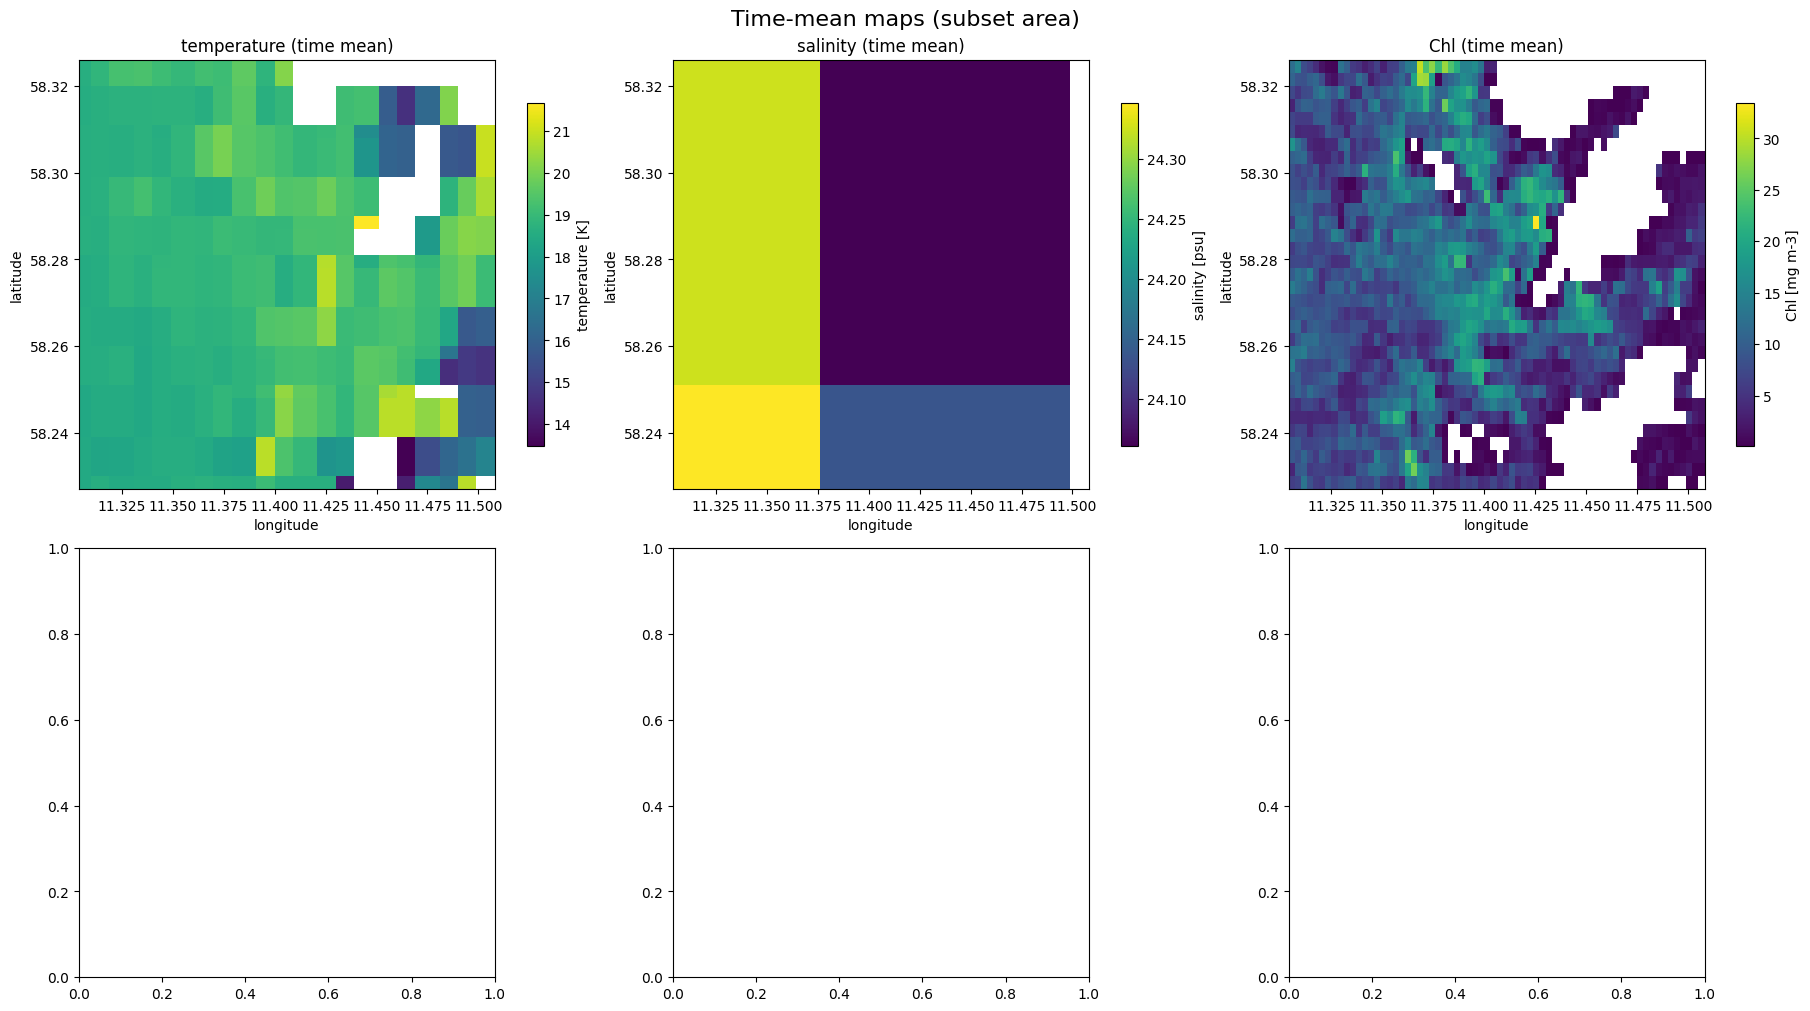

In [64]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Best practice: inspect inputs before running the model.
# This cell produces:
#   1. Six spatial time-mean maps showing geographic patterns
#   2. Temperature/salinity and food-variable time series at
#      the central pixel to check temporal variability.
# If a variable looks flat/random it came from fake-data fallback and model results for it will not be physical.


# Quick guard
if ds_daily is None or len(ds_daily.coords.get('time', [])) == 0:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    # Plot spatial time-mean maps for key variables
    # vars_to_map = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
    vars_to_map = ['temperature', 'salinity', 'Chl']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    axes = axes.ravel()

    for ax, var in zip(axes, vars_to_map):
        if var in ds_daily:
            try:
                da_mean = ds_daily[var].mean(dim='time')
                im = da_mean.plot(ax=ax, cmap='viridis', add_colorbar=True, cbar_kwargs={'shrink': 0.8})
                ax.set_title(f"{var} (time mean)")
                ax.set_xlabel("longitude")
                ax.set_ylabel("latitude")
            except Exception as e:
                ax.text(0.5, 0.5, f"Plot failed: {e}", ha='center')
        else:
            ax.text(0.5, 0.5, f"{var} not found", ha='center')

    plt.suptitle("Time-mean maps (subset area)", fontsize=16)
    # plt.savefig("ds_daily_time_mean_maps.png", dpi=150)
    plt.show()


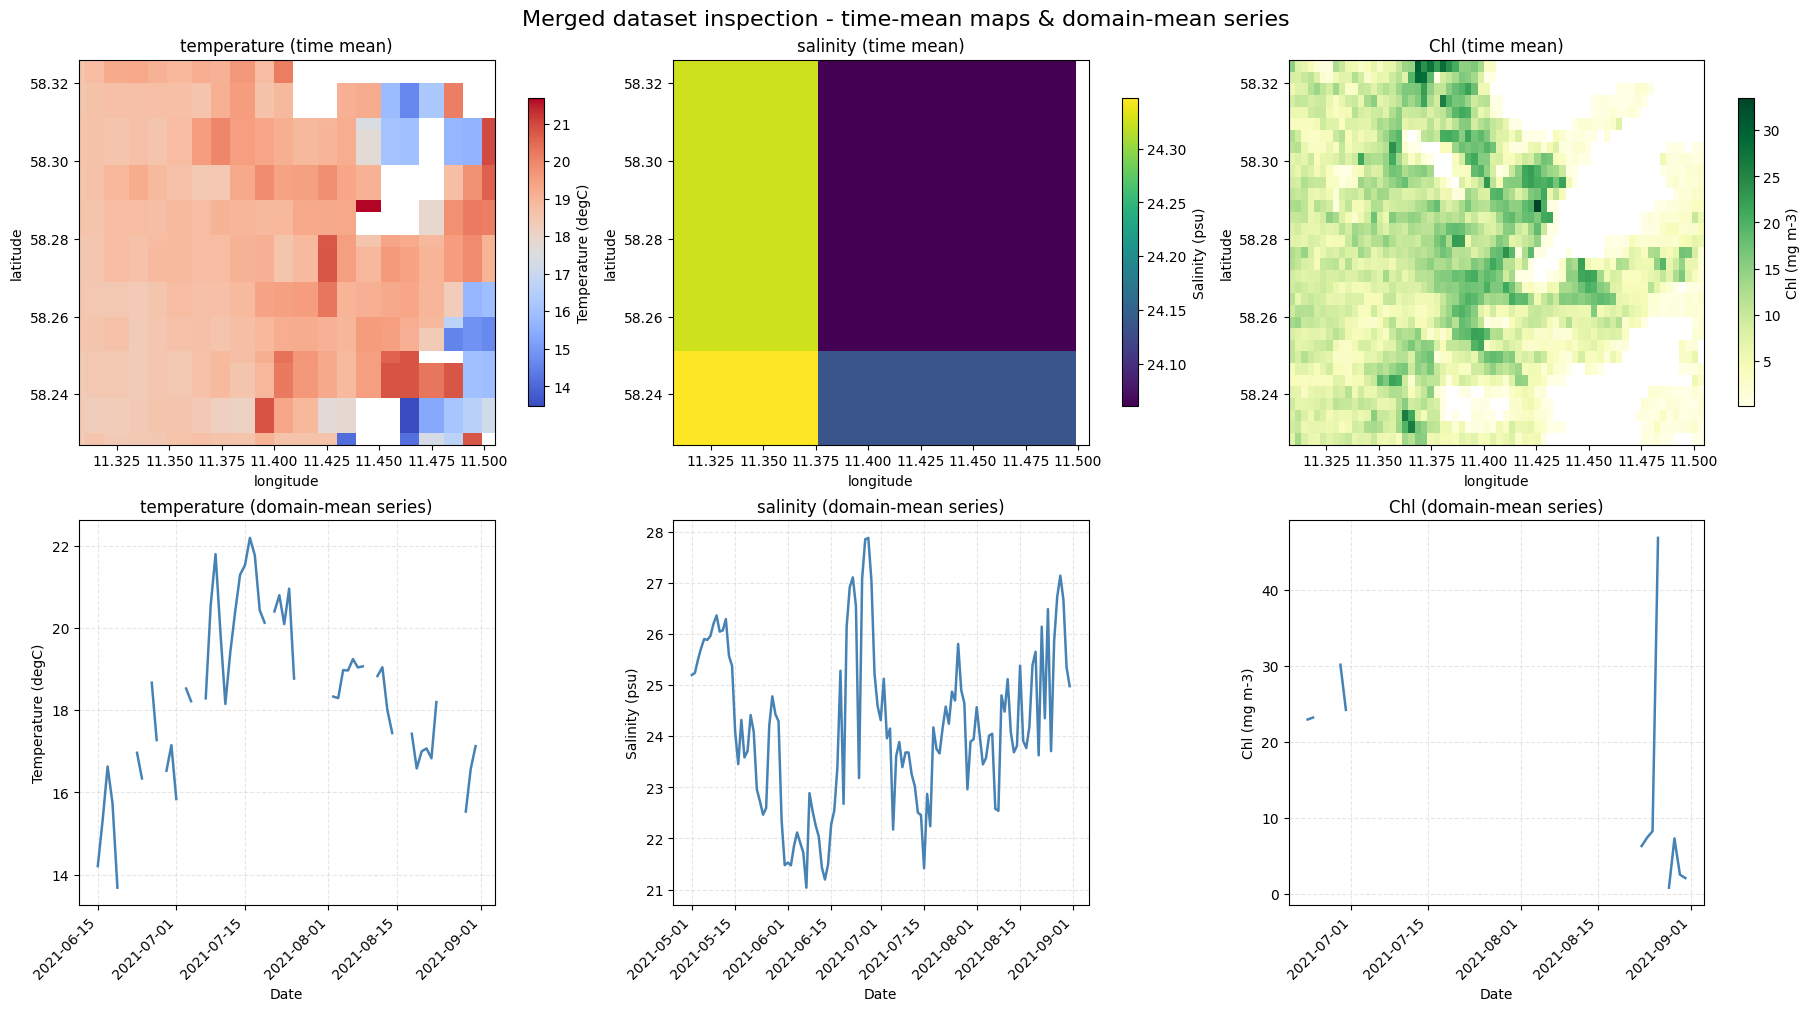

In [23]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Inspect the combined cube before running the model.
#   Top row    : spatial time-mean maps  (geographic pattern per variable)
#   Bottom row : domain-mean daily series (temporal variability per variable)

# ds_daily = combined_data

vars_to_plot = [
    ("temperature", "Temperature (degC)", "coolwarm"),
    ("salinity",    "Salinity (psu)",     "viridis"),
    ("Chl",  "Chl (mg m-3)",       "YlGn"),
]

if ds_daily is None or 'time' not in ds_daily.dims:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    for col, (var, label, cmap) in enumerate(vars_to_plot):
        ax_map, ax_ts = axes[0, col], axes[1, col]

        if var not in ds_daily:
            ax_map.text(0.5, 0.5, f"{var} not found", ha='center')
            ax_ts.text(0.5, 0.5, f"{var} not found", ha='center')
            continue

        da = ds_daily[var]

        # --- top: spatial time-mean map ---
        da.mean(dim='time').plot(
            ax=ax_map, cmap=cmap, add_colorbar=True,
            cbar_kwargs={'shrink': 0.8, 'label': label},
        )
        ax_map.set_title(f"{var} (time mean)")
        ax_map.set_xlabel("longitude")
        ax_map.set_ylabel("latitude")

        # --- bottom: domain-mean daily time series ---
        ts = da.mean(dim=['latitude', 'longitude'])
        ax_ts.plot(ds_daily['time'], ts, color='steelblue', lw=1.8)
        ax_ts.set_title(f"{var} (domain-mean series)")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel(label)
        ax_ts.grid(True, alpha=0.3, ls='--')
        for t in ax_ts.get_xticklabels():
            t.set_rotation(45)
            t.set_ha('right')

    plt.suptitle("Merged dataset inspection - time-mean maps & domain-mean series",
                 fontsize=16)
    # plt.savefig("ds_daily_inspection.png", dpi=150)
    plt.show()

In [24]:
# # Prepare variables to plot
# vars_to_show = ['temperature', 'salinity', 'Chl', 'POC', 'POM', 'TPM']
# available_vars = [v for v in vars_to_show if v in ds_daily]

# if len(available_vars) == 0:
#     print("No variables available in ds_daily to create folium map.")
# else:
#     lat_vals = ds_daily.latitude.values
#     lon_vals = ds_daily.longitude.values
#     lat_min, lat_max = float(lat_vals.min()), float(lat_vals.max())
#     lon_min, lon_max = float(lon_vals.min()), float(lon_vals.max())
#     bounds = [[lat_min, lon_min], [lat_max, lon_max]]
#     center = [(lat_min + lat_max) / 2.0, (lon_min + lon_max) / 2.0]

#     # Is latitude stored ascending (south -> north)?
#     lat_ascending = bool(lat_vals[0] < lat_vals[-1])

#     m = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

#     def array_to_dataurl(arr2d, cmap_name='viridis', vmin=None, vmax=None):
#         """2D array (lat x lon) -> PNG data URL.
#            Folium maps image row 0 to the NORTH edge, so row 0 must be the
#            northernmost latitude. We orient based on the actual lat ordering."""
#         arr = np.array(arr2d, dtype=float)
#         # Make row 0 == northernmost. If lats are ascending (row 0 = south),
#         # flip vertically; if already descending (row 0 = north), leave as is.
#         if lat_ascending:
#             arr = np.flipud(arr)
#         mask = np.isnan(arr)

#         if vmin is None:
#             vmin = np.nanpercentile(arr, 2)
#         if vmax is None:
#             vmax = np.nanpercentile(arr, 98)
#         if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
#             vmin, vmax = np.nanmin(arr), np.nanmax(arr)
#             if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax == vmin:
#                 vmax = vmin + 1.0

#         norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
#         cmap = mpl.colormaps[cmap_name]          # replaces deprecated mpl.cm.get_cmap
#         mapped = cmap(norm(arr))                  # RGBA float [0,1]
#         mapped[..., 3][mask] = 0.0                # transparent where NaN

#         rgba8 = (mapped * 255).astype(np.uint8)
#         im = Image.fromarray(rgba8, mode='RGBA')
#         bio = io.BytesIO()
#         im.save(bio, format='PNG')
#         b64 = base64.b64encode(bio.getvalue()).decode('ascii')
#         return f"data:image/png;base64,{b64}"

#     var_cmaps = {
#         'temperature': 'viridis', 'salinity': 'plasma', 'Chl': 'YlGn',
#         'POC': 'YlOrBr', 'POM': 'OrRd', 'TPM': 'inferno',
#     }

#     first_added = False
#     for var in available_vars:
#         try:
#             da_mean = ds_daily[var].mean(dim='time').values
#             if da_mean.ndim != 2:
#                 da_mean = np.squeeze(da_mean)
#                 if da_mean.ndim != 2:
#                     print(f"Skipping {var}: not 2D after squeeze")
#                     continue

#             cmap = var_cmaps.get(var, 'viridis')
#             vmin = np.nanpercentile(da_mean, 2)
#             vmax = np.nanpercentile(da_mean, 98)
#             data_url = array_to_dataurl(da_mean, cmap_name=cmap, vmin=vmin, vmax=vmax)

#             folium.raster_layers.ImageOverlay(
#                 name=var, image=data_url, bounds=bounds,
#                 opacity=0.8 if not first_added else 1.0,
#                 interactive=True, cross_origin=False, zindex=1,
#             ).add_to(m)
#             first_added = True

#             try:
#                 lc = linear.__getattribute__(cmap).scale(
#                     float(np.nanmin(da_mean)), float(np.nanmax(da_mean)))
#                 lc.caption = f"{var} (time mean)"
#                 lc.add_to(m)
#             except Exception:
#                 pass
#         except Exception as e:
#             print(f"Failed to add overlay for {var}: {e}")

#     folium.LayerControl(collapsed=False).add_to(m)

#     js = """
#     <script>
#     function makeOverlaysRadio(){
#       var lc = document.getElementsByClassName('leaflet-control-layers')[0];
#       if(!lc) { setTimeout(makeOverlaysRadio, 200); return; }
#       var inputs = lc.querySelectorAll('input');
#       for(var i=0; i<inputs.length; i++){
#         if(inputs[i].type === 'checkbox'){
#           inputs[i].type = 'radio';
#           inputs[i].name = 'overlayGroup';
#         }
#       }
#     }
#     setTimeout(makeOverlaysRadio, 500);
#     </script>
#     """
#     from folium import Element
#     m.get_root().html.add_child(Element(js))
#     print("Folium map built.")

# try:
#     display(m)
# except Exception:
#     pass

In [30]:
# ============================================================
# RECHUNK FOR OPTIMAL DASK PERFORMANCE
# ============================================================
# After subsetting and interpolation, Dask's internal chunk
# boundaries may be irregular. Rechunking reorganises them into
# uniform tiles:
#   time: -1  -> one chunk for the full time axis (required;
#               ShellSIM cannot be split along time)
#   lat: 80, lon: 110 -> spatial tile footprint
# After rechunking each Dask task processes one complete tile
# with no overlap, minimising scheduler overhead.
#
# RAM tip: if you encounter MemoryErrors, halve lat/lon chunk
# sizes. Each chunk ~ lat * lon * time_steps * 8 bytes * n_vars.

# Rechunk for optimal performance
# After all the merging and interpolating, Dask's chunks can get fragmented, rechunk so every Dask task receives 
# a data chunk of the exact size


# large_dataset
# dataset_chunk = {'time': -1, 'latitude': 18, 'longitude': 35}

# small dataset
dataset_chunk = {'time': -1, 'latitude': -1, 'longitude': -1}

print("Rechunking dataset for optimal performance")
# Force Dask backing AND explicit spatial tiling.
# time stays as ONE chunk (ShellSIM cannot be split along time);
# latitude/longitude are tiled so each Dask task = one spatial tile.
# ds_daily = ds_daily.chunk({
#     'time': -1,        # whole time axis (required — ShellSIM can't split time)
#     'latitude': 18,    # 35 -> 2 tiles (18 + 17)
#     'longitude': 35,   # 69 -> 2 tiles (35 + 34)
# })

# if  whole cube is ~30 MB, one tile is also perfectly fine and simplest:
ds_daily = ds_daily.chunk(dataset_chunk)

print("Rechunked dataset")
print("Is dask-backed:", bool(ds_daily.chunks))   # should print True
print(ds_daily.chunks)

# and gives 4 roughly equal tiles.




Rechunking dataset for optimal performance
Rechunked dataset
Is dask-backed: True
Frozen({'time': (123,), 'latitude': (33,), 'longitude': (66,)})


# ShellSIM model wrapper   
takes a 1D numpy array (time-series for one pixel) as input. run entire for loop (time-stepping) and return a 1D numpy array of the result ( eg soft tissue energy time-series). Then Apply in Parallel, using xr.apply_ufunc to apply wrapper function to the gridded data. tell apply_ufunc that the "core dimension" is time, which instructs it to parallelize over all other dimensions (lat, lon)

In [31]:
# ============================================================
# SHELLSIM MODEL CONSTANTS AND WRAPPER FUNCTION
# ============================================================
# N_STATES  = 11 : internal state variables integrated by pyfabm
# N_DIAGS   =  2 : diagnostic outputs (TFW, SL) — from pyfabm
#                  diagnostic_variables, NOT part of model.state
# N_OUTPUTS = 13 : total rows returned per pixel (states + diags)
#
# VARIABLE_NAMES order MUST exactly match the row order filled
# inside the time loop: rows 0–10 = 11 state variables,
# row 11 = TFW, row 12 = SL.
#
# run_fabm_at_point_full (fixes applied):
#   1. Uses len(T_ts) instead of outer-scope time_horizon_len so
#      the function is self-contained and safe in Dask workers.
#   2. Clamps food concentrations (Chl/POC/POM/TPM) to >= 0.
#      Negative concentrations from bad/fake data cause forward-
#      Euler to diverge within a few steps.
#   3. Updates number_of_days_since_start_of_the_year every step
#      so seasonal physiology is correct across the full period.
#   4. redirect_stdout now covers the ENTIRE function body so
#      all FABM print output goes to the log file, not stdout.
# ============================================================

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"

N_STATES  = 8   # pyfabm internal state variables (model.state[:] length)
N_DIAGS   = 2    # diagnostic outputs: TFW (row 11), SL (row 12)
N_OUTPUTS = N_STATES + N_DIAGS  # = 13 — total rows returned per pixel

# Authoritative names list — length must equal N_OUTPUTS (13).
# Method 2 imports this directly; do NOT redefine STATE_NAMES elsewhere.
VARIABLE_NAMES = [
    'soft_tissue_energy', 'shell_energy', 
    'aging', 
    'C1',
    'C2', 
    'C3',
    'Chl_state', 
    # 'POC_state', 
    # 'POM_state', 
    # 'TPM_state',
    
    'O2',  # rows 0–10
    'TFW', 
    'SL'# rows 11–12
]

assert len(VARIABLE_NAMES) == N_OUTPUTS, (
    f"VARIABLE_NAMES has {len(VARIABLE_NAMES)} entries but N_OUTPUTS={N_OUTPUTS}"
)


def run_fabm_at_point_full(T_ts, S_ts, Chl_ts,
                           # POC_ts=None, POM_ts=None, TPM_ts=None,
                           log_filename=None
                          ):

    """
    Runs the FABM/ShellSIM time-loop for a single spatial pixel.

    Parameters
    ----------
    T_ts, S_ts          : 1-D float arrays, length n_steps
        Temperature (°C) and practical salinity (PSU) time series.
    Chl_ts, POC_ts,
    POM_ts, TPM_ts      : 1-D float arrays, length n_steps
        Food-variable time series (mg m-3).  Values < 0 are clamped
        to 0 before being passed to the model (negative concentrations
        are unphysical and cause forward-Euler divergence).
    log_filename        : str
        Path to the append-mode log file that receives all FABM
        print/diagnostic output (keeps Jupyter stdout clean).

    Returns
    -------
    numpy.ndarray, shape (N_OUTPUTS=13, n_steps)
        Rows  0–10 : pyfabm state variables (model.state[:])
        Row  11    : TFW  diagnostic [g]
        Row  12    : Shell Length diagnostic [cm]
        All-NaN on land pixels or when any input is NaN / non-finite.
    """
    # ── n_steps is taken directly from the input arrays, NOT from the
    #    outer-scope time_horizon_len, so this function is safe to call
    #    from Dask workers that were serialised with a stale closure. ──
    n_steps = len(T_ts)




    # ── Guard: reject land / missing-data pixels ────────────────────
    all_inputs = [T_ts, S_ts, Chl_ts,
                  # POC_ts, POM_ts, TPM_ts
                 
                 ]
    if any(np.any(np.isnan(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)
    if not all(np.all(np.isfinite(a)) for a in all_inputs):
        return np.full((N_OUTPUTS, n_steps), np.nan)

    # ── Clamp food concentrations to physically valid range ─────────
    # Negative concentrations are unphysical (artefacts of linear
    # interpolation or fake test data).  Passing them to the model
    # causes the forward-Euler integration to diverge within a few
    # steps, producing NaN or runaway values for the entire run.
    Chl_ts  = np.maximum(Chl_ts,  0.0)
    # POC_ts  = np.maximum(POC_ts,  0.0)
    # POM_ts  = np.maximum(POM_ts,  0.0)
    # TPM_ts  = np.maximum(TPM_ts,  0.0)

    try:
        # ── redirect_stdout covers the FULL function body so that
        #    pyfabm print output during both init AND getRates() goes
        #    to the log file rather than flooding Jupyter output. ────
        with open(log_filename, 'a') as f_log:
            with redirect_stdout(f_log):
                    
                model = pyfabm.Model(
                    
                    "/home/jovyan/work/ShellSIM_Trials/notebook_timeseries/notebook_dropdowns/partial_fabm.yaml"
                )

                # ── Static (time-invariant) dependencies ────────────
                model.cell_thickness = 1.0
                model.dependencies["seeding_rate"].value  = 0.0
                model.dependencies["harvest_ratio"].value = 0.0
                model.dependencies["current_speed"].value = 1.0
                model.dependencies["air_exposure"].value  = 0.0

                # ── Initialise from day-0 forcing values ─────────────
                model.dependencies["temperature"].value        = float(T_ts[0])
                model.dependencies["practical_salinity"].value = float(S_ts[0])
                model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                    pd.Timestamp(time_horizon[0]).dayofyear
                )
                model.findStateVariable('Chl1/Chl').value = float(Chl_ts[0])
                # model.findStateVariable('POC1/POC').value = float(POC_ts[0])
                # model.findStateVariable('POM1/POM').value = float(POM_ts[0])
                # model.findStateVariable('TPM1/TPM').value = float(TPM_ts[0])

                if not model.start():
                    raise RuntimeError("FABM model failed to start internally.")

                # ── Output array ─────────────────────────────────────
                outputs = np.zeros((N_OUTPUTS, n_steps))

                for nd in range(n_steps):
                    # ── Update day-of-year (drives seasonal physiology) ──
                    model.dependencies["number_of_days_since_start_of_the_year"].value = float(
                        pd.Timestamp(time_horizon[nd]).dayofyear
                    )

                    # ── Update environmental forcings ────────────────
                    model.dependencies["temperature"].value        = float(T_ts[nd])
                    model.dependencies["practical_salinity"].value = float(S_ts[nd])
                    model.findStateVariable('Chl1/Chl').value      = float(Chl_ts[nd])
                    # model.findStateVariable('POC1/POC').value      = float(POC_ts[nd])
                    # model.findStateVariable('POM1/POM').value      = float(POM_ts[nd])
                    # model.findStateVariable('TPM1/TPM').value      = float(TPM_ts[nd])

                    # ── Forward-Euler step (same as original 1-D notebook) ──
                    state_rates = model.getRates()
                    model.state[:] += state_rates * 86400.0

                    # ── Guard: catch state blow-up immediately ────────────
                    # If any state variable is NaN or Inf (e.g. from a cube-
                    # root / log of a negative energy reserve when the oyster
                    # starves), pyfabm silently propagates bad values for all
                    # remaining steps without raising an exception.
                    # Detect it here, fill remaining outputs with NaN, and
                    # break — this preserves the valid data already computed
                    # up to this timestep rather than discarding it.
                    if not np.all(np.isfinite(np.array(model.state[:]))):
                        outputs[:, nd:] = np.nan
                        break

                    # ── Store state variables (rows 0–10) ────────────
                    outputs[:N_STATES, nd] = np.array(model.state[:])

                    # ── Store diagnostics (rows 11–12) ───────────────
                    outputs[N_STATES,     nd] = model.diagnostic_variables['Oyster/TFW'].value
                    outputs[N_STATES + 1, nd] = model.diagnostic_variables['Oyster/Shell_Length'].value

        return outputs  # shape (N_OUTPUTS=13, n_steps)

    except RuntimeError:
        warnings.warn(f"FABM failed to start: {pyfabm.getError()}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

    except Exception as e:
        warnings.warn(f"FABM error at pixel: {str(e)}")
        return np.full((N_OUTPUTS, n_steps), np.nan)

## Most optimal processing method:  parallelize over the spatial dimensions (latitude, longitude) using xarray.apply_ufunc.  
chunking only the spatial dimensions (latitude and longitude) tells Dask to split the map into tiles, but keep the full time series for each pixel intact.

In [32]:
ds_daily

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 123, latitude: 33, longitude: 66)
Coordinates:
  * time         (time) datetime64[ns] 984B 2021-05-01 2021-05-02 ... 2021-08-31
  * latitude     (latitude) float64 264B 58.32 58.32 58.32 ... 58.23 58.23 58.23
  * longitude    (longitude) float64 528B 11.31 11.31 11.31 ... 11.5 11.5 11.5
Data variables:
    temperature  (time, latitude, longitude) float32 1MB dask.array<chunksize=(123, 33, 66), meta=np.ndarray>
    salinity     (time, latitude, longitude) float32 1MB dask.array<chunksize=(123, 33, 66), meta=np.ndarray>
    Chl          (time, latitude, longitude) float32 1MB dask.array<chunksize=(123, 33, 66), meta=np.ndarray>

In [33]:
time_horizon_len = ds_daily.time.size
output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"

In [34]:
# ============================================================
# METHOD 1 —  RUN For Small area 
# ============================================================

In [35]:
# ============================================================
# MATERIALISE FORCING INPUTS BEFORE GOING DISTRIBUTED
# ============================================================
# datacube.load returns arrays whose Dask graph holds lazy
# rasterio/odc reader objects (a lambda + a weakref). The default
# threaded scheduler never pickles them, but dask.distributed MUST
# pickle the graph to ship it to worker PROCESSES -> that is the
# "Can't pickle ... <lambda>" / "cannot pickle weakref" crash.
#
# Computing here — BEFORE the Client is created, so it runs on the
# local threaded scheduler — turns those readers into plain numpy.
# We then re-chunk so apply_ufunc(dask='parallelized') still tiles
# over latitude/longitude. The graph shipped to workers is now just
# numpy data + the (importable) wrapper function = fully picklable.

# try:
#     client.close()
# except NameError:
#     pass

# ds_daily = (
#     ds_daily[['temperature', 'salinity', 'Chl']]
#     .drop_vars('spatial_ref', errors='ignore')
#     .compute()                          # no client active now -> local scheduler
#     .chunk({'time': -1, 'latitude': 18, 'longitude': 35})
# )
# print('Inputs materialised and rechunked:', dict(ds_daily.chunks))

# force the local scheduler on this compute
ds_daily = (
    ds_daily[['temperature', 'salinity', 'Chl']]
    .drop_vars('spatial_ref', errors='ignore')
    .compute(scheduler='synchronous')   # <-- bypass the already-active distributed Client
    .chunk(dataset_chunk)
)
print('Inputs materialised and rechunked:', dict(ds_daily.chunks))




Inputs materialised and rechunked: {'time': (123,), 'latitude': (33,), 'longitude': (66,)}


In [36]:
# ============================================================
# METHOD 1: APPLY_UFUNC — PARALLEL SPATIAL APPLICATION
# ============================================================
# xr.apply_ufunc applies run_fabm_at_point_full across every
# (lat, lon) pixel in parallel via Dask.
#
# Key settings:
#   input_core_dims=[['time']]*6 : time is the 'core' dimension
#     consumed by the function; Dask parallelises over lat x lon.
#   output_core_dims=[['state','time']] : wrapper returns (13,T).
#   vectorize=True : loops pixel-by-pixel (needed for pyfabm).
#   dask='parallelized' : each spatial chunk becomes a Dask task.
#
# --- WHY dask.distributed WITH PROCESSES ---
# pyfabm holds C-level global state and is NOT thread-safe.
# Using process-based workers gives each worker its own memory
# space and its own pyfabm instance, preventing race conditions.
# n_workers=4, threads_per_worker=2 gives 8 concurrent slots;
# adjust n_workers to match your CPU count (cpu_count // 2).

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_LOG_FILENAME = f"fabm_run_log_{timestamp}.log"


from dask.distributed import Client

# Start process-based local cluster (thread-safe for pyfabm)
# IMPORTANT: threads_per_worker MUST be 1.
# pyfabm has C-level global state that is NOT thread-safe.
# Two concurrent pyfabm instances in the SAME process (threads)
# will corrupt each other's model state silently.
client = Client(n_workers=4, threads_per_worker=1, processes=True)
print('Dask dashboard:', client.dashboard_link)

print('Setting up parallel computation with apply_ufunc ...')

result_full = xr.apply_ufunc(
    run_fabm_at_point_full,
    ds_daily['temperature'],   
    ds_daily['salinity'],
    ds_daily['Chl'],
    # ds_daily['POC'],
    # ds_daily['POM'],
    # ds_daily['TPM'],
    input_core_dims=[['time']] * 3,
    output_core_dims=[['state', 'time']],
    exclude_dims=set(('time',)),
    dask='parallelized',
    vectorize=True,
    output_dtypes=[float],
    kwargs={'log_filename': RUN_LOG_FILENAME},
    dask_gufunc_kwargs={
        'allow_rechunk': True,
        'output_sizes': {'state': N_OUTPUTS, 'time': time_horizon_len}
    }
)

# Restore coordinate labels on the output dimensions
result_full = result_full.assign_coords(time=time_horizon)
result_full = result_full.assign_coords(state=VARIABLE_NAMES)

# Promote 'state' coordinate slices into separate Dataset variables
result_dataset = result_full.to_dataset(dim='state')

# Attach CF-convention metadata attributes
result_dataset['soft_tissue_energy'].attrs = {'units': 'J', 'long_name': 'Soft Tissue Energy'}
result_dataset['shell_energy'].attrs = {'units': 'J', 'long_name': 'Shell Energy'}
result_dataset['aging'].attrs = {'units': 'days', 'long_name': 'Aging'}
result_dataset['C1'].attrs = {'units': '', 'long_name': 'C1 State Variable'}
result_dataset['C2'].attrs = {'units': '', 'long_name': 'C2 State Variable'}
result_dataset['C3'].attrs = {'units': '', 'long_name': 'C3 State Variable'}
result_dataset['Chl_state'].attrs = {'units': 'mg/m3', 'long_name': 'Chlorophyll State'}
# result_dataset['POC'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Carbon State'}
# result_dataset['POM'].attrs = {'units': 'mg/m3', 'long_name': 'Particulate Organic Matter State'}
# result_dataset['TPM'].attrs = {'units': 'mg/m3', 'long_name': 'Total Particulate Matter State'}
result_dataset['O2'].attrs = {'units': 'mg/L', 'long_name': 'Oxygen State'}
result_dataset['SL'].attrs = {'units': 'cm', 'long_name': 'Shell Length'}
result_dataset['TFW'].attrs = {'units': 'g', 'long_name': 'Total Fresh Weight'}

print('\nTask graph built. Result Dataset has 13 variables.')
print(result_dataset)

Dask dashboard: http://127.0.0.1:8787/status
Setting up parallel computation with apply_ufunc ...

Task graph built. Result Dataset has 13 variables.
<xarray.Dataset> Size: 21MB
Dimensions:             (latitude: 33, longitude: 66, time: 123)
Coordinates:
  * latitude            (latitude) float64 264B 58.32 58.32 ... 58.23 58.23
  * longitude           (longitude) float64 528B 11.31 11.31 11.31 ... 11.5 11.5
  * time                (time) datetime64[ns] 984B 2021-05-01 ... 2021-08-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 2MB dask.array<chunksize=(33, 66, 123), meta=np.ndarray>
    shell_energy        (latitude, longitude, time) float64 2MB dask.array<chunksize=(33, 66, 123), meta=np.ndarray>
    aging               (latitude, longitude, time) float64 2MB dask.array<chunksize=(33, 66, 123), meta=np.ndarray>
    C1                  (latitude, longitude, time) float64 2MB dask.array<chunksize=(33, 66, 123), meta=np.ndarray>
    C2                  (l

# Run computation and Save  
Call .compute() or .to_netcdf() on the result. This triggers Dask to execute the parallel computation and write the final 3D output file.

In [37]:
# ============================================================
# TRIGGER COMPUTATION AND SAVE WITH ZLIB COMPRESSION
# ============================================================
# Calling .to_netcdf() on the Dask-backed Dataset triggers all
# queued tasks and streams results directly to disk so peak RAM
# stays near: one_chunk_size x num_workers.

# encoding: enables zlib (deflate) compression at level 4 for
# all 13 output variables. Level 4 gives a good trade-off:
# typically 3-5x size reduction vs uncompressed with negligible
# read-time overhead. chunksizes=(1,65,92) makes single time-
# slice reads contiguous on disk.


# ========================= code to run ===========================

# Build compression encoding dict for all 13 output variables
_compress_enc = {'zlib': True, 'complevel': 4, 'chunksizes': (1, 65, 92)}
encoding = {var: _compress_enc for var in VARIABLE_NAMES}

print('Now running dask computation ...')
with ProgressBar():
    result_dataset.to_netcdf(output_file_name, compute=True, encoding=encoding)

print(f'****** SUCCESS: Results saved to {output_file_name} *******')

# Release distributed workers when done
client.close()

Now running dask computation ...
****** SUCCESS: Results saved to gridded_oyster_output_ALL_STATES_batched.nc *******


In [38]:
# ============================================================
# OPTIONAL MEMORY CLEANUP
# ============================================================
# Uncomment these lines after saving to free RAM, especially
# important if continuing to Method 2 or the analysis sections
# below on a machine with limited memory.

# # Clean up
# del ds_poc  
# del ds_sal
# del ds_temp
# del ds_chl
# del ds_pom
# del ds_tpm
# del ds_daily, result_sten
# gc.collect()

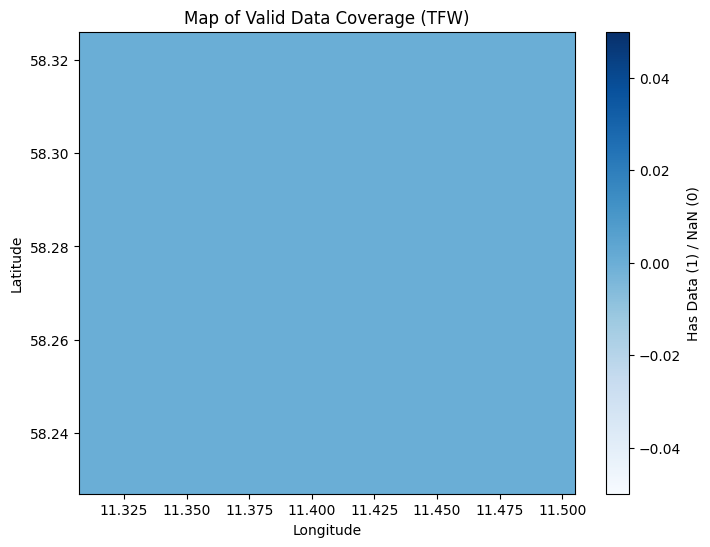


Examine the map above to visually pick a coordinate (blue area) to plot.


In [39]:
# ============================================================
# DATA COVERAGE MAP
# ============================================================
# Creates a spatial map showing which pixels contain valid
# (non-NaN) model output vs which are all-NaN (land or where
# all inputs were missing). Blue pixels = valid model output;
# white pixels = no data. Use this map to identify regions
# suitable for aquaculture analysis.

# 1. Create a boolean map: True if a pixel has ANY non-NaN data over time
#    .any(dim='time') collapses the time dimension, leaving only (lat, lon)
data_coverage = ~result_dataset['TFW'].isnull().all(dim='time')

# 2. Plot the coverage map
plt.figure(figsize=(8, 6))
# We use .plot() from xarray directly for simplicity
data_coverage.plot(
    cmap='Blues', 
    cbar_kwargs={'label': 'Has Data (1) / NaN (0)'}
)
plt.title('Map of Valid Data Coverage (TFW)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print("\nExamine the map above to visually pick a coordinate (blue area) to plot.")

In [41]:
# ============================================================
# SINGLE-POINT TIME SERIES PLOTS
# ============================================================
# Reads directly from the saved netCDF output file so results
# are persistent across kernel restarts and cover all batches.
# result_dataset is NOT used here — it only holds the last
# tile in memory and is discarded after the batch loop.
# ============================================================

OUTPUT_FILE = "gridded_oyster_output_ALL_STATES_batched.nc"

# Mask sentinel error values (-99) and non-finite values written
# by ShellSIM on pixels that failed internally.
ds_out = xr.open_dataset(OUTPUT_FILE)
ds_out

<xarray.Dataset> Size: 21MB
Dimensions:             (latitude: 33, longitude: 66, time: 123)
Coordinates:
  * latitude            (latitude) float64 264B 58.32 58.32 ... 58.23 58.23
  * longitude           (longitude) float64 528B 11.31 11.31 11.31 ... 11.5 11.5
  * time                (time) datetime64[ns] 984B 2021-05-01 ... 2021-08-31
Data variables:
    soft_tissue_energy  (latitude, longitude, time) float64 2MB ...
    shell_energy        (latitude, longitude, time) float64 2MB ...
    aging               (latitude, longitude, time) float64 2MB ...
    C1                  (latitude, longitude, time) float64 2MB ...
    C2                  (latitude, longitude, time) float64 2MB ...
    C3                  (latitude, longitude, time) float64 2MB ...
    Chl_state           (latitude, longitude, time) float64 2MB ...
    O2                  (latitude, longitude, time) float64 2MB ...
    TFW                 (latitude, longitude, time) float64 2MB ...
    SL                  (latitude, longitude, time) float64 2MB ...
Attributes:
    units:         K
    nodata:        nan
    crs:           EPSG:4326
    grid_mapping:  spatial_ref

Plotting time series for point: Lat=58.258995, Lon=11.346692
Nearest pixel found at: Lat=58.258, Lon=11.348
⚠️  Data at this point is all NaN (land or missing input data).
   Try a different coordinate — see the data coverage map cell.


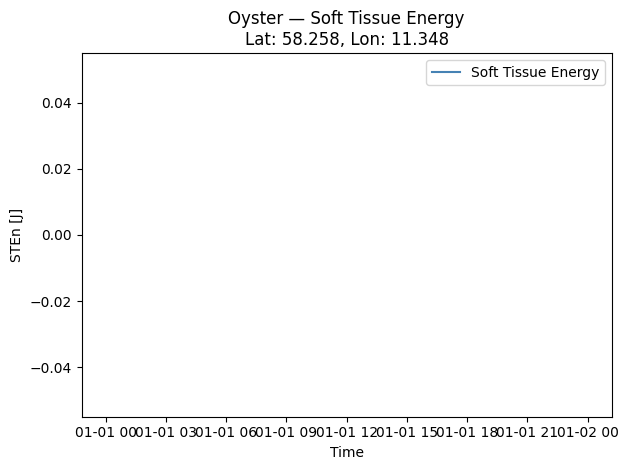

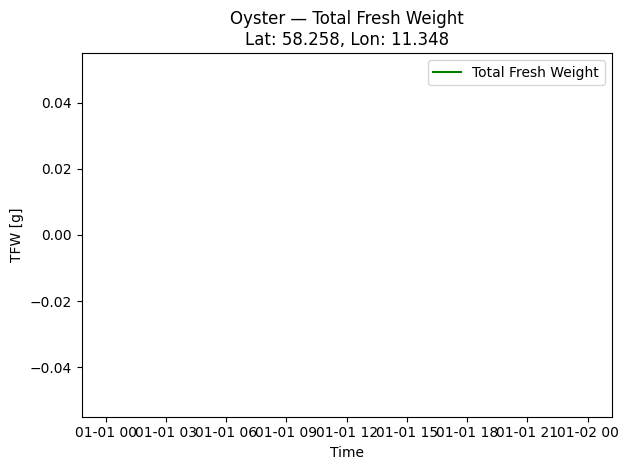

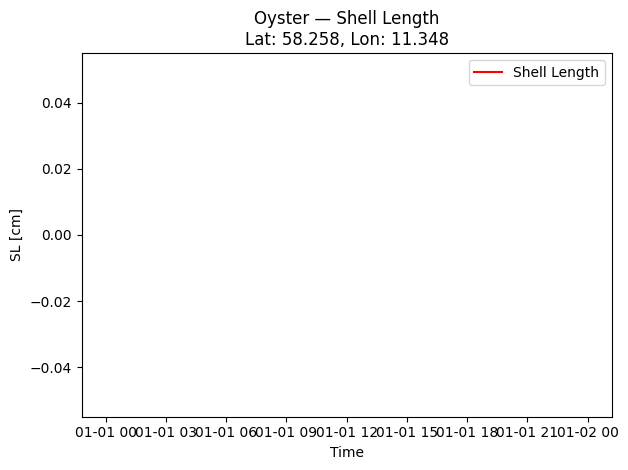

In [42]:



ds_out = ds_out.where(ds_out > -90)          # mask ShellSIM -99 sentinels
for var in ds_out.data_vars:
    ds_out[var] = ds_out[var].where(np.isfinite(ds_out[var].values))


plot_lat = 58.258995
plot_lon = 11.346692
print(f"Plotting time series for point: Lat={plot_lat}, Lon={plot_lon}")

try:
    single_point_data = ds_out.sel(
        latitude=plot_lat,
        longitude=plot_lon,
        method='nearest'
    ).load()

    actual_lat = float(single_point_data.latitude)
    actual_lon = float(single_point_data.longitude)
    print(f"Nearest pixel found at: Lat={actual_lat:.3f}, Lon={actual_lon:.3f}")

    all_nan = single_point_data.soft_tissue_energy.isnull().all()
    if all_nan:
        print("⚠️  Data at this point is all NaN (land or missing input data).")
        print("   Try a different coordinate — see the data coverage map cell.")

    # ── Plot 1: Soft Tissue Energy ──
    fig1, ax1 = plt.subplots()
    ax1.plot(single_point_data.time, single_point_data.soft_tissue_energy,
             label='Soft Tissue Energy', color='steelblue')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('STEn [J]')
    ax1.set_title(f'Oyster — Soft Tissue Energy\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax1.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Total Fresh Weight ──
    fig2, ax2 = plt.subplots()
    ax2.plot(single_point_data.time, single_point_data.TFW,
             label='Total Fresh Weight', color='green')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('TFW [g]')
    ax2.set_title(f'Oyster — Total Fresh Weight\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax2.legend()
    plt.tight_layout()
    plt.show()

    # ── Plot 3: Shell Length ──
    fig3, ax3 = plt.subplots()
    ax3.plot(single_point_data.time, single_point_data.SL,
             label='Shell Length', color='red')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('SL [cm]')
    ax3.set_title(f'Oyster — Shell Length\n'
                  f'Lat: {actual_lat:.3f}, Lon: {actual_lon:.3f}')
    ax3.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error selecting data for plotting: {e}")
    print("Check that the output file exists and the coordinates fall within the domain.")

In [37]:
# # ============================================================
# # METHOD 2 — MEMORY-OPTIMISED BATCHED GRIDDED RUN For Large area 
# # ============================================================
# # Key fixes vs the previous version:
# #   1. Uses N_OUTPUTS (13) everywhere — NOT N_STATES (11).
# #      The wrapper returns 13 rows; telling apply_ufunc to expect
# #      11 causes a silent broadcast / shape mismatch error.
# #   2. Uses VARIABLE_NAMES (defined in the wrapper cell) as the
# #      authoritative 13-entry list so TFW and SL are written.
# #   3. Creates netCDF variables for ALL 13 outputs including
# #      TFW and SL before the tile loop begins.
# #   4. Writes TFW and SL into the output file exactly like the
# #      other state variables — no special-casing needed because
# #      they are just rows 11–12 of the returned array.
# # ============================================================

# time_horizon_len = ds_daily.time.size
# output_file_name = "gridded_oyster_output_ALL_STATES_batched.nc"

# # --- use the authoritative list from the wrapper cell ---
# # VARIABLE_NAMES has 13 entries: 11 states + TFW + SL
# # N_OUTPUTS = 13  (both defined in the wrapper cell above)

# # ============================================================
# # CHUNK INFO
# # ============================================================
# try:
#     lat_chunks = ds_daily.chunks['latitude']
#     lon_chunks = ds_daily.chunks['longitude']
# except Exception:
#     raise RuntimeError(
#         "ds_daily must be Dask-backed and chunked in latitude/longitude"
#     )

# lat_indices = np.cumsum([0] + list(lat_chunks))
# lon_indices = np.cumsum([0] + list(lon_chunks))

# total_lat = int(ds_daily.sizes["latitude"])
# total_lon = int(ds_daily.sizes["longitude"])

# # ============================================================
# # CREATE OUTPUT FILE ONCE — all 13 variables including TFW, SL
# # ============================================================
# if os.path.exists(output_file_name):
#     os.remove(output_file_name)

# nc = netCDF4.Dataset(output_file_name, "w", format="NETCDF4")

# nc.createDimension("time",      time_horizon_len)
# nc.createDimension("latitude",  total_lat)
# nc.createDimension("longitude", total_lon)

# # coordinate variables
# time_var = nc.createVariable("time", "f8", ("time",))
# time_seconds = (
#     pd.to_datetime(ds_daily.time.values)
#     .astype("datetime64[s]")
#     .astype(np.int64)
# )
# time_var[:]       = time_seconds
# time_var.units    = "seconds since 1970-01-01 00:00:00"
# time_var.calendar = "standard"

# lat_var        = nc.createVariable("latitude",  "f4", ("latitude",))
# lat_var[:]     = ds_daily.latitude.values.astype(np.float32)
# lat_var.units  = getattr(ds_daily["latitude"], "units", "degrees_north")

# lon_var        = nc.createVariable("longitude", "f4", ("longitude",))
# lon_var[:]     = ds_daily.longitude.values.astype(np.float32)
# lon_var.units  = getattr(ds_daily["longitude"], "units", "degrees_east")

# # one netCDF variable per output (13 total — states + TFW + SL)
# for name in VARIABLE_NAMES:
#     v = nc.createVariable(
#         name, "f4",
#         ("time", "latitude", "longitude"),
#         zlib=True, complevel=4,
#         fill_value=np.float32(np.nan),
#     )
#     # attach human-readable metadata
#     if name == "TFW":
#         v.long_name = "Total Fresh Weight"
#         v.units     = "g"
#     elif name == "SL":
#         v.long_name = "Shell Length"
#         v.units     = "cm"

# nc.sync()
# nc.close()

# print(f"Output file created: {output_file_name}")
# print(f"Variables to write ({len(VARIABLE_NAMES)}): {VARIABLE_NAMES}\n")
# print(f"Starting batched computation -> {output_file_name}")

# # ============================================================
# # PROCESS TILES AND WRITE
# # ============================================================
# for i in range(len(lat_chunks)):
#     lat_start = int(lat_indices[i])
#     lat_end   = int(lat_indices[i + 1])

#     for j in range(len(lon_chunks)):
#         lon_start = int(lon_indices[j])
#         lon_end   = int(lon_indices[j + 1])

#         print(
#             f"\nBatch Lat {i+1}/{len(lat_chunks)} ({lat_start}:{lat_end})  "
#             f"Lon {j+1}/{len(lon_chunks)} ({lon_start}:{lon_end})"
#         )

#         ds_subset = ds_daily.isel(
#             latitude=slice(lat_start, lat_end),
#             longitude=slice(lon_start, lon_end),
#         )

#         # apply_ufunc: vectorize over (lat, lon), keeping time as core dim.
#         # output_sizes MUST use N_OUTPUTS (13) — the wrapper returns 13 rows.
#         result_full_batch = xr.apply_ufunc(
#             run_fabm_at_point_full,
#             ds_subset["temperature"],
#             ds_subset["salinity"],
#             ds_subset["Chl"],
#             # ds_subset["POC"],
#             # ds_subset["POM"],
#             # ds_subset["TPM"],
#             input_core_dims=[["time"]] * 6,
#             output_core_dims=[["state", "time"]],
#             exclude_dims={"time"},
#             vectorize=True,
#             dask="parallelized",
#             output_dtypes=[float],
#             kwargs={"log_filename": RUN_LOG_FILENAME},
#             dask_gufunc_kwargs={
#                 "allow_rechunk": True,
#                 "output_sizes": {
#                     "state": N_OUTPUTS,      # <-- 13, not 11
#                     "time":  time_horizon_len,
#                 },
#             },
#         )

#         # Attach coordinate labels so to_dataset(dim='state') works correctly
#         result_full_batch = result_full_batch.assign_coords(
#             time=ds_subset.time,
#             state=VARIABLE_NAMES,            # <-- 13-entry list
#         )

#         result_dataset_batch = result_full_batch.to_dataset(dim="state")

#         with ProgressBar():
#             result_dataset_batch.load()

#         # ── Debug summary ──
#         print("\nChunk output summary:")
#         for var_name in VARIABLE_NAMES:
#             arr    = result_dataset_batch[var_name].values
#             total  = arr.size
#             nans   = np.isnan(arr).sum()
#             try:
#                 lo, hi = np.nanmin(arr), np.nanmax(arr)
#             except ValueError:
#                 lo = hi = np.nan
#             print(
#                 f"  {var_name:22s}  NaN%={100*nans/total:6.2f}  "
#                 f"min={lo:.4g}  max={hi:.4g}"
#             )

#         # ── Write tile into pre-created netCDF ──
#         nc = netCDF4.Dataset(output_file_name, "r+")
#         try:
#             for var_name in VARIABLE_NAMES:
#                 da = result_dataset_batch[var_name]

#                 # Identify dim names (apply_ufunc may return lat/lon in any order)
#                 dims     = list(da.dims)
#                 time_dim = next(d for d in dims if "time" in d.lower())
#                 lat_dim  = next(d for d in dims if "lat"  in d.lower())
#                 lon_dim  = next(d for d in dims if "lon"  in d.lower())

#                 arr = (
#                     da.transpose(time_dim, lat_dim, lon_dim)
#                     .values
#                     .astype(np.float32)
#                 )

#                 if arr.shape[0] != time_horizon_len:
#                     raise ValueError(
#                         f"Time-axis mismatch for '{var_name}': "
#                         f"got {arr.shape[0]}, expected {time_horizon_len}. "
#                         f"Full shape: {arr.shape}"
#                     )

#                 nc.variables[var_name][
#                     :, lat_start:lat_end, lon_start:lon_end
#                 ] = arr

#                 print(
#                     f"  Wrote {var_name:22s}  shape={arr.shape}  "
#                     f"NaNs={np.isnan(arr).sum()}"
#                 )

#             nc.sync()
#         finally:
#             nc.close()

#         del result_full_batch, result_dataset_batch, ds_subset
#         gc.collect()

# print(f"\n✅ Success: all batches processed and saved to {output_file_name}")

RuntimeError: ds_daily must be Dask-backed and chunked in latitude/longitude

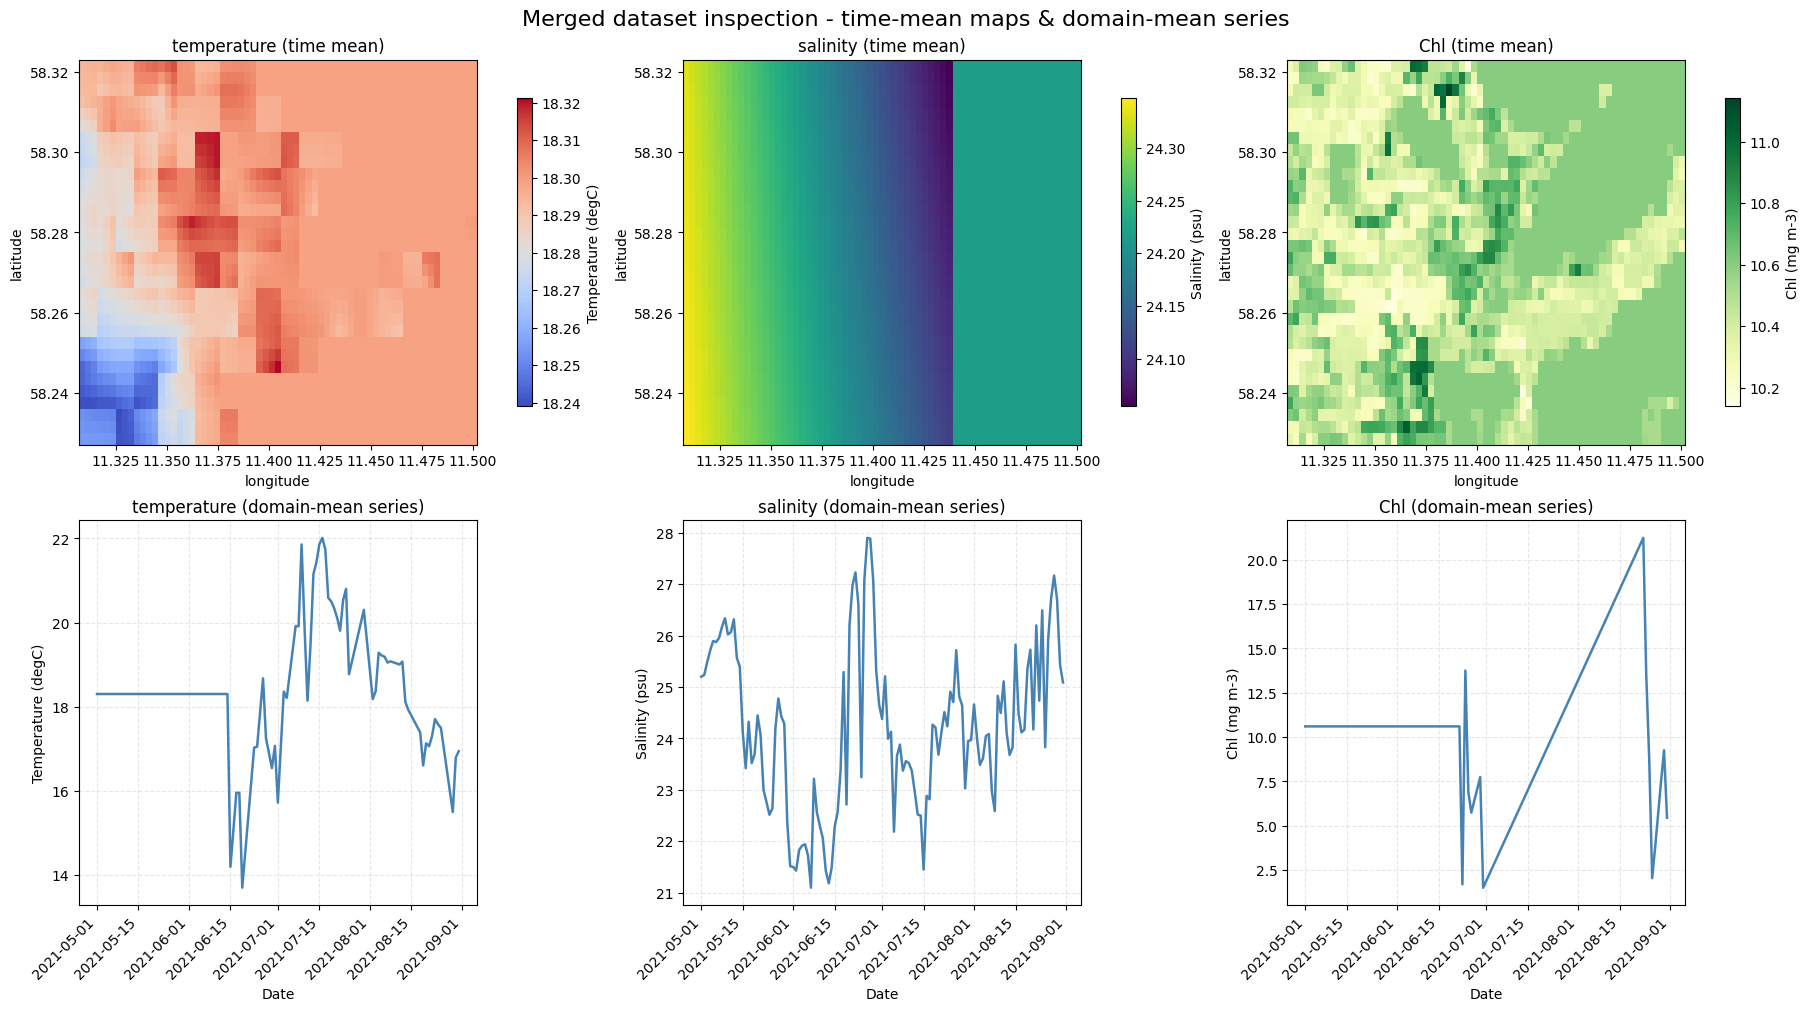

In [35]:
# ============================================================
# EXPLORATORY VISUALISATION OF MERGED DATA
# ============================================================
# Inspect the combined cube before running the model.
#   Top row    : spatial time-mean maps  (geographic pattern per variable)
#   Bottom row : domain-mean daily series (temporal variability per variable)
# A variable that looks flat or implausible should be checked upstream.

vars_to_plot = [
    ("temperature", "Temperature (degC)", "coolwarm"),
    ("salinity",    "Salinity (psu)",     "viridis"),
    ("Chl",         "Chl (mg m-3)",       "YlGn"),
]

if ds_daily is None or 'time' not in ds_daily.dims:
    print("ds_daily is empty or has no time dimension. Skipping plotting.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

    for col, (var, label, cmap) in enumerate(vars_to_plot):
        ax_map, ax_ts = axes[0, col], axes[1, col]

        if var not in ds_daily:
            ax_map.text(0.5, 0.5, f"{var} not found", ha='center')
            ax_ts.text(0.5, 0.5, f"{var} not found", ha='center')
            continue

        da = ds_daily[var]

        # --- top: spatial time-mean map ---
        da.mean(dim='time').plot(
            ax=ax_map, cmap=cmap, add_colorbar=True,
            cbar_kwargs={'shrink': 0.8, 'label': label},
        )
        ax_map.set_title(f"{var} (time mean)")
        ax_map.set_xlabel("longitude")
        ax_map.set_ylabel("latitude")

        # --- bottom: domain-mean daily time series ---
        ts = da.mean(dim=['latitude', 'longitude'])
        ax_ts.plot(ds_daily['time'], ts, color='steelblue', lw=1.8)
        ax_ts.set_title(f"{var} (domain-mean series)")
        ax_ts.set_xlabel("Date")
        ax_ts.set_ylabel(label)
        ax_ts.grid(True, alpha=0.3, ls='--')
        for t in ax_ts.get_xticklabels():
            t.set_rotation(45)
            t.set_ha('right')

    plt.suptitle("Merged dataset inspection - time-mean maps & domain-mean series",
                 fontsize=16)
    # plt.savefig("ds_daily_inspection.png", dpi=150)
    plt.show()